## `emulate_hsc.ipynb` 

This notebook simulates how we extract from Buzzard Mocks an HSC-type catalog by mimicking the selection of HSC.

Idea :
- Bin HSC sources on a high-resolution healpix map to infer source density
- Draw N sources respecting the catalog magnitude distributions
- Assert it is correct by comparing to the true catalog 

## Step 1 : Binning HSC sources on a healpix map

In [1]:
import fitsio as fio 
import numpy as np 
import pandas as pd 
import healpy as hp
import cmocean.cm as cmo
import matplotlib.pyplot as plt
from numpy.lib import recfunctions as rfn

from astropy.table import Table, vstack
from pathlib import Path

HSC_CATALOG = Path(
    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
)
buzzard_index = 0
ROOT_BUZZARD = Path(
    f'/global/cfs/projectdirs/desi/mocks/buzzard/buzzard_v2.0/buzzard-{buzzard_index}/addgalspostprocess'
    )
TRUTH = ROOT_BUZZARD / 'truth'
DESI_TGTS = ROOT_BUZZARD / 'desi_targets_v1.2'
MAGS = ROOT_BUZZARD / 'surveymags'

OUTPUT_SIM = Path(
    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/sims/hsc_sim.fits'
)

class BuzzardCatalog():
    def __init__(self, buzzard_index):
        self.nside_buzzard = 8
        self.buzzard_index = buzzard_index
        self.ROOT_ALL = Path(
            '/global/cfs/projectdirs/desi/mocks/buzzard/buzzard_v2.0'
            )
        self.ROOT_BUZZARD = Path(
            self.ROOT_ALL,
            f'buzzard-{self.buzzard_index}/addgalspostprocess'
            )
        self.TRUTH = ROOT_BUZZARD / 'truth'
        self.DESI_TGTS = ROOT_BUZZARD / 'desi_targets_v1.2'
        self.MAGS = ROOT_BUZZARD / 'surveymags'

        self.files_pix = self.TRUTH.glob('Chinchilla-11_cam_rs_scat_shift_lensed.*.fits')
        self.pix_nums = sorted([int(pix.name.split('.')[1]) for pix in self.files_pix])
            
    def fetch_truth(self, pix):
        return Path(
            self.TRUTH, 
            f'Chinchilla-{self.buzzard_index}_cam_rs_scat_shift_lensed.{pix}.fits'
            )
    
    def fetch_surveymag(self, pix):
        return Path(
            self.MAGS,
            f'surveymags-aux.{pix}.fits'
        )

    def fetch_desi_target(self, pix):
        return Path(
            self.DESI_TGTS,
            f'Chinchilla-0_cam_rs_scat_shift_lensed.{pix}.fits'
        )
    
    def transform_pixels(self, sim_pixels, ra_flip=False, dec_flip=False):
        theta, phi = hp.pix2ang(self.nside_buzzard, sim_pixels, nest=True)
        if ra_flip:
            phi = (phi + np.pi) % (2 * np.pi)
        if dec_flip:
            theta = np.pi - theta
        return hp.ang2pix(self.nside_buzzard, theta, phi, nest=True)

In [ ]:
## Get HSC coordinates
hsc_tbl_all = fio.FITS(HSC_CATALOG)
# We move HSC coordinates to a location on the sky covered by Buzzard mocks (NW corner)
# We do field by field and join afterwards the catalogs. Once the field is moved, 
# sample on where buzzard actually is by limiting ra, dec coordinates
offset_ra = 260
offset_dec = 20
ra_all = (hsc_tbl_all[1]['RA'].read() + offset_ra) % 360
dec_all = hsc_tbl_all[1]['DEC'].read() + offset_dec
assert np.sum(dec_all > 90) == 0
# limiting ourselves to the NW corner
bds_mask = (0 < ra_all) & (ra_all < 180) & (0 < dec_all)
ra_hsc = ra_all[bds_mask]
dec_hsc = dec_all[bds_mask]

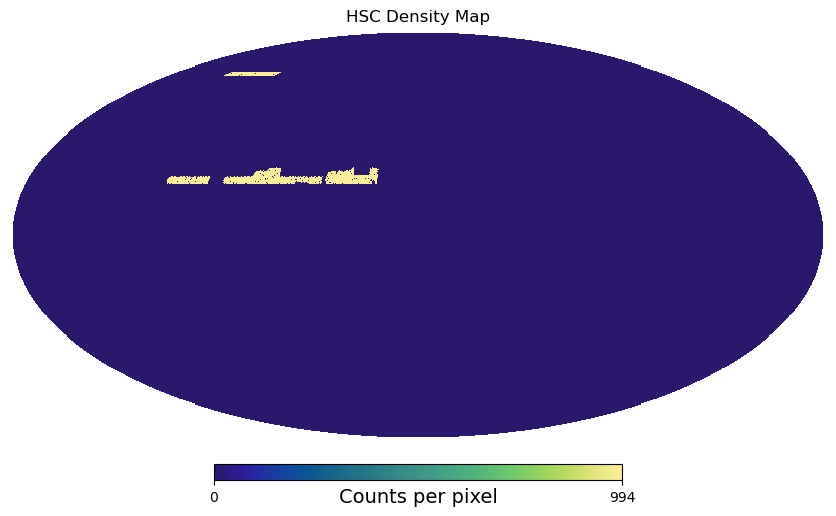

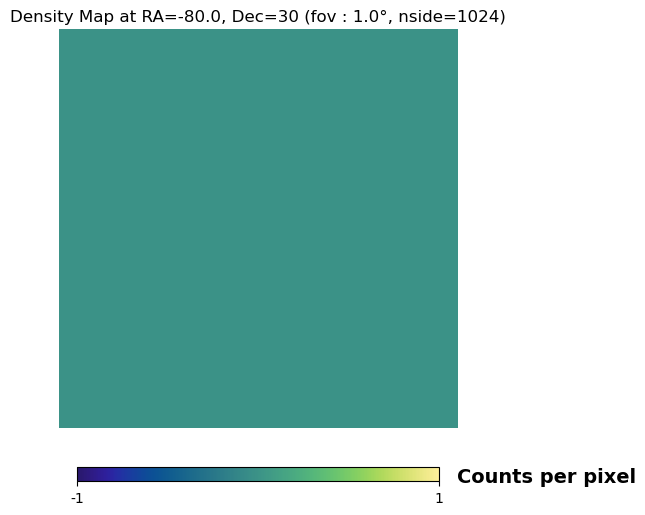

In [6]:
nside_hsc = 1024
npix_hsc = hp.nside2npix(nside_hsc)
theta = np.radians(90.0 - dec_hsc) 
phi = np.radians(ra_hsc)
hsc_pix_indices = hp.ang2pix(nside_hsc, theta, phi, nest=True)
hsc_hp_map = np.bincount(hsc_pix_indices, minlength=npix_hsc)

hp.mollview(
    hsc_hp_map,
    title="HSC Density Map",
    unit="Counts per pixel",
    norm="hist",
    cmap=cmo.haline,
    nest=True,
)
plt.show()

# === Zoom configuration ===
center_ra = -80.0  
center_dec = 30
half_width = 1.0
# ==========================

hp.cartview(
    hsc_hp_map,
    lonra=[center_ra - half_width, center_ra + half_width],
    latra=[center_dec - half_width, center_dec + half_width],
    rot=(center_ra, center_dec),
    title=f"Density Map at RA={center_ra}, Dec={center_dec} (fov : {half_width}°, nside={nside_hsc})",
    unit="Counts per pixel",
    norm="hist",
    cmap=cmo.haline,
    nest=True,
    cbar=True,
)

In [19]:
# Lensed magnitude
bc = BuzzardCatalog(buzzard_index=0)
pix = 0
mag = fio.FITS(bc.fetch_surveymag(pix=pix))
true = fio.FITS(bc.fetch_truth(pix=pix))
filters = np.loadtxt('filters.txt', dtype=str)
mag_index = list(filters).index('DECAM_i')

15 low-res pixels are covered.
List: [  7  13  16  17  18  19  20  24  74  75  96  97  98 379 382]


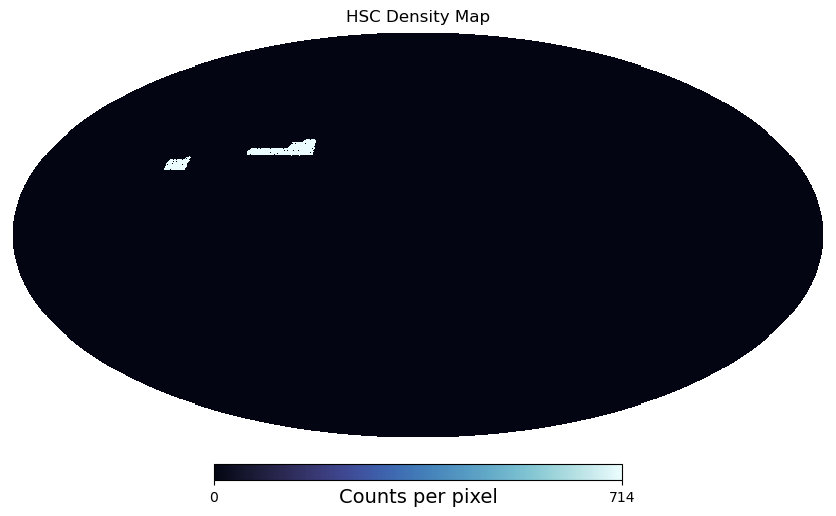

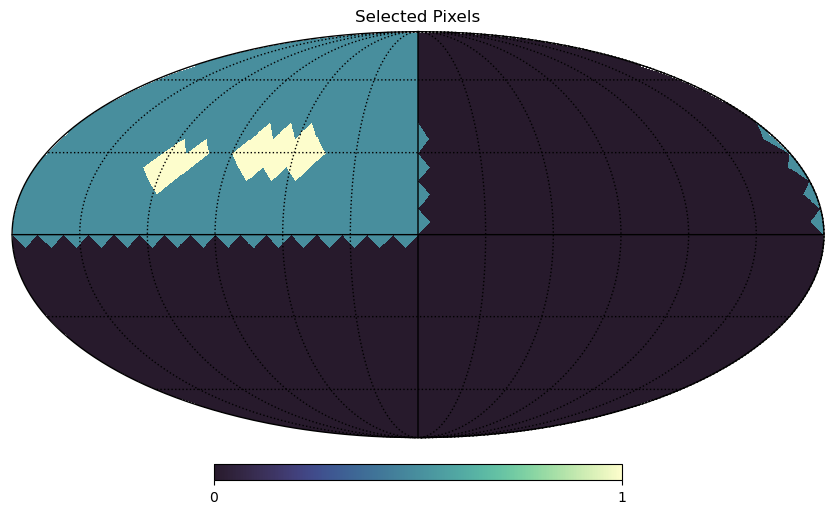

In [17]:
nside_buzzard = bc.nside_buzzard

map_low = np.zeros(hp.nside2npix(nside_buzzard))
nonzero_high = np.flatnonzero(hsc_hp_map > 0)

theta, phi = hp.pix2ang(nside_hsc, nonzero_high, nest=True)

low_pixels = hp.ang2pix(nside_buzzard, theta, phi, nest=True)
unique_low_pixels = np.unique(low_pixels)

print(f"{len(unique_low_pixels)} low-res pixels are covered.")
print("List:", unique_low_pixels)

npix = hp.nside2npix(nside_buzzard)
hmap = np.zeros(npix)

pixels_path = Path('/global/cfs/projectdirs/desi/mocks/buzzard/buzzard_v2.0/buzzard-11/addgalspostprocess/truth')
listpix = pixels_path.glob('Chinchilla-11_cam_rs_scat_shift_lensed.*.fits')
pix_nums = sorted([int(pix.name.split('.')[1]) for pix in listpix])

# Set value 1.0 for the selected pixels
hmap[pix_nums] = 0.5
hmap[unique_low_pixels] = 1

# Plot the map
hp.mollview(hsc_hp_map, title="HSC Density Map", unit="Counts per pixel", norm="hist", cmap=cmo.ice, nest=True)
hp.mollview(hmap, title="Selected Pixels", nest=True, cmap=cmo.deep_r)
hp.graticule()
plt.show()

In [20]:
# now that this part of the HSC field lands in the buzzard field,
# we can generate our emulated HSC catalog. 

# For each pixel that we have in the HSC catalog, we grab the corresponding tile
# from the Buzzard catalog. 
tiles_nonnull_hsc = np.flatnonzero(hsc_hp_map > 0)
theta, phi = hp.pix2ang(nside_hsc, tiles_nonnull_hsc, nest=True)
tiles_buzzard = hp.ang2pix(nside_buzzard, theta, phi, nest=True)

tiles_buzzard_to_hsc = {}
for t_buzzard, t_hsc in zip(tiles_buzzard, tiles_nonnull_hsc):
    try:
        tiles_buzzard_to_hsc[t_buzzard].append(t_hsc)
    except KeyError:
        tiles_buzzard_to_hsc[t_buzzard] = [t_hsc]

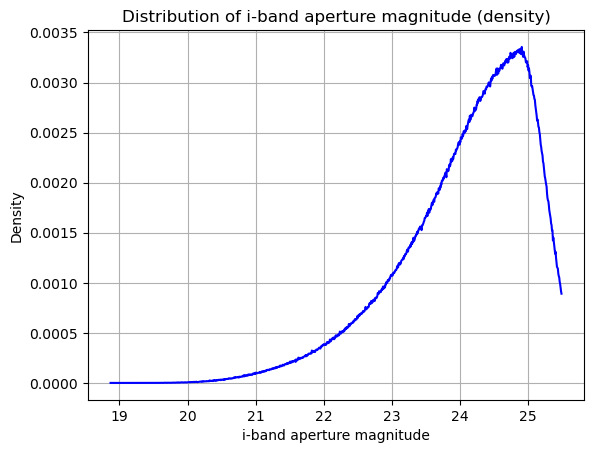

In [22]:
## let's get the probability distribution of HSC
i_mag_aperture = hsc_tbl_all[1]['i_aperture_mag'].read()[bds_mask]
counts_imagpdf, bin_edges_imagpdf = np.histogram(i_mag_aperture, bins=1000, density=False)
counts_imagpdf = counts_imagpdf / np.sum(counts_imagpdf)

plt.plot(bin_edges_imagpdf[:-1], counts_imagpdf, label='HSC i-band aperture magnitude', color='blue')
plt.title('Distribution of i-band aperture magnitude (density)')
plt.xlabel('i-band aperture magnitude')
plt.ylabel('Density')
plt.grid()

In [24]:
mag_index = list(filters).index('DECAM_i')
tbpix_keys = list(tiles_buzzard_to_hsc.keys())
buzzard_truth = []
mag_truth = []
for index, (tbpix, thpixs) in enumerate(tiles_buzzard_to_hsc.items()):
    print(
        f"Processing tile {tbpix} with {len(thpixs)} HSC tiles ({index+1}/{len(tbpix_keys)})"
        )
    with fio.FITS(bc.fetch_truth(tbpix)) as f:
        truth = f[1].read(columns=['ID', 'RA', 'DEC', 'PX', 'PY', 'PZ'])
        ra_truth = truth['RA']
        dec_truth = truth['DEC']
        theta_truth = np.radians(90.0 - dec_truth)
        phi_truth = np.radians(ra_truth)

    with fio.FITS(bc.fetch_surveymag(tbpix)) as f:
        mags = f[1].read(columns=['LMAG', 'Z'])
    
    imag = mags['LMAG'][:, mag_index]
    mags = rfn.drop_fields(mags, 'LMAG')
    mags = rfn.append_fields(mags, 'IMAG', imag, usemask=False)

    pix_truth_hsc = hp.ang2pix(nside_hsc, theta_truth, phi_truth, nest=True)
    print(
        f"Found {len(truth)} sources in tile {tbpix} with {len(mags)} magnitudes. Finished loading files\n"
        )
    
    mid_truth = []
    mid_mag = []
    cnt_wrong_dens = 0
    for k, thp in enumerate(thpixs):

        in_thp = pix_truth_hsc == thp
        n_draw = int(hsc_hp_map[thp]) 
        # here : add some slight noise to the density 
        n_draw = int(n_draw + n_draw * np.random.normal(0, 1/n_draw**2))

        if not np.any(in_thp) or n_draw == 0:
            print(f"Skipping tile {thp} with no sources or no HSC sources")
            continue

        # Sample randomly from sources in this tile
        indices_in_thp = np.where(in_thp)[0]
        # Assign each imag value to a bin
        bin_indices = np.digitize(imag[indices_in_thp], bin_edges_imagpdf) - 1
        valid = (bin_indices >= 0) & (bin_indices < len(counts_imagpdf))

        if not np.any(valid):
            print(f"Skipping tile {thp} with no valid sources")
            continue

        bin_indices = bin_indices[valid]
        indices_in_thp = indices_in_thp[valid]
        try:
            probs = counts_imagpdf[bin_indices] / np.sum(counts_imagpdf[bin_indices])
            nonzero_mask = probs > 0
            probs = probs[nonzero_mask]
        except ZeroDivisionError:
            print(f"ZeroDivisionError for tile {thp} with {len(indices_in_thp)} sources")
            probs = np.ones(len(bin_indices)) / len(bin_indices)
            nonzero_mask = np.ones(len(bin_indices), dtype=bool)
            cnt_wrong_dens += 1
        
        indices_in_thp = indices_in_thp[nonzero_mask]
        n_to_sample = min(n_draw, len(indices_in_thp))
        if len(indices_in_thp) < n_draw:
            cnt_wrong_dens +=1

        if k % int(len(thpixs)//5) == 0:
            print(
                f"Tile {thp} has {len(indices_in_thp)} sources, "
                f"expecting to sample {n_to_sample} with probs {probs[:2]}, "
                f"valid sources percentage {np.sum(valid)/len(valid)*100:.1f}%, "
                f"progress {k}/{len(thpixs)} [{100*(k+1)/len(thpixs):.1f}%]"
                )
            
        select_ind = np.random.choice(
            # here we give the probability of sampling to the sources based on the magnitude distribution
            indices_in_thp, 
            size=n_to_sample, 
            replace=False, 
            p=probs
            )

        mini_truth = truth[select_ind]
        mini_mag = mags[select_ind]
        mid_truth.append(mini_truth)
        mid_mag.append(mini_mag)
    
    print(f'\nNumber of wrong densities: {cnt_wrong_dens}')
    print(f'Expected counts = {np.sum(hsc_hp_map[thpixs])}, Found counts = {sum(len(mt) for mt in mid_truth)}\n')

    # Concatenate the results
    tile_truth_table = Table(np.concatenate(mid_truth))
    tile_truth_table['RA'] -= offset_ra
    tile_truth_table['DEC'] -= offset_dec
    mid_mag_conc = np.concatenate(mid_mag)
    tile_truth_table['IMAG'] = mid_mag_conc['IMAG']
    tile_truth_table['Z'] = mid_mag_conc['Z']
    del mid_mag_conc
    tile_truth_table.write(f"temp_tiles/tile_{tbpix}.fits", overwrite=True)

tables = [Table.read(f) for f in Path('temp_tiles').glob("*.fits")]
final_table = vstack(tables)
final_table['RA'] -= offset_ra
final_table['DEC'] -= offset_dec
final_table.write('test_hsc_buzzard.fits', overwrite=True)

Processing tile 7 with 112 HSC tiles (1/15)
Found 16178494 sources in tile 7 with 16178494 magnitudes. Finished loading files

Tile 130527 has 501 sources, expecting to sample 68 with probs [9.94233322e-07 1.00666124e-05], valid sources percentage 65.0%, progress 0/112 [0.9%]
Tile 130936 has 680 sources, expecting to sample 12 with probs [2.58915884e-06 4.77237456e-04], valid sources percentage 64.3%, progress 22/112 [20.5%]
Tile 131004 has 625 sources, expecting to sample 404 with probs [2.89021685e-05 6.58006036e-05], valid sources percentage 55.5%, progress 44/112 [40.2%]
Tile 131026 has 579 sources, expecting to sample 514 with probs [0.00039721 0.00094926], valid sources percentage 60.4%, progress 66/112 [59.8%]
Tile 131048 has 510 sources, expecting to sample 510 with probs [1.17551272e-05 6.09129317e-05], valid sources percentage 53.5%, progress 88/112 [79.5%]
Tile 131070 has 581 sources, expecting to sample 416 with probs [1.04543448e-07 1.01825318e-04], valid sources percentag

In [8]:
i_mag = hsc_tbl_all[1]['i_cm_mag'].read()[bds_mask]
i_mag_nonnan = i_mag[~np.isnan(i_mag)]

NameError: name 'bds_mask' is not defined

In [ ]:
i_mag_aperture = hsc_tbl_all[1]['i_aperture_mag'].read()[bds_mask]

Text(0.5, 1.0, 'HSC true i-band magnitude distribution')

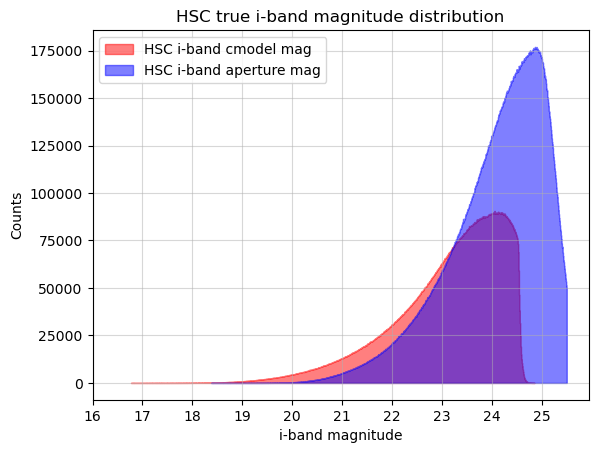

In [ ]:
## Get the magnitude distribution in i-band
bins = 1000

counts_ihsc, bin_edges_ihsc = np.histogram(i_mag_nonnan, bins=bins)
bin_centers = 0.5 * (bin_edges_ihsc[:-1] + bin_edges_ihsc[1:])
plt.fill_between(
    bin_centers, counts_ihsc, step='mid', alpha=0.5, color='red', label='HSC i-band cmodel mag'
)

counts_ihsc_aperture, bin_edges_ihsc_aperture = np.histogram(i_mag_aperture, bins=bins)
bin_centers_aperture = 0.5 * (bin_edges_ihsc_aperture[:-1] + bin_edges_ihsc_aperture[1:])
plt.fill_between(
    bin_centers_aperture, counts_ihsc_aperture, step='mid', alpha=0.5, color='blue', label='HSC i-band aperture mag'
)
plt.xlabel("i-band magnitude")
plt.ylabel("Counts")
plt.legend()
plt.grid(True, alpha=0.5)
plt.xticks(ticks=np.arange(16, 26, 1))
plt.title("HSC true i-band magnitude distribution")

## Magnitude sampling

Following curves and nan magnitudes, let's go with i_aperture_mag as our fiducial magnitude to draw samples from. Let's first plot the distribution of magnitudes from Buzzard.

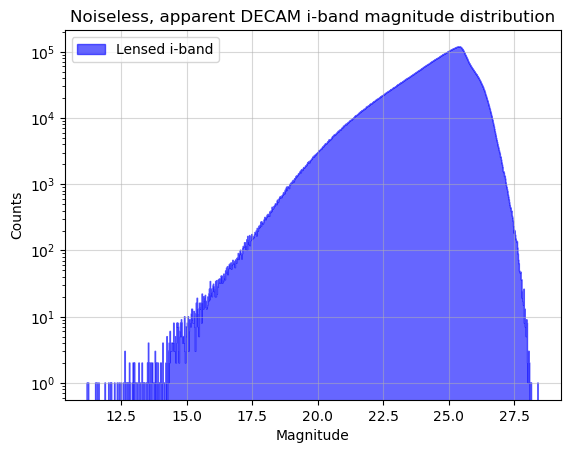

In [16]:
bounds = (np.min(lens_ap_mag_i), np.max(lens_ap_mag_i))
counts_ibuzzard, bin_edges_ibuzzard = np.histogram(lens_ap_mag_i, bins=1000, range=bounds)
bin_centers_i = 0.5 * (bin_edges_ibuzzard[:-1] + bin_edges_ibuzzard[1:])
plt.fill_between(
    bin_centers_i, counts_ibuzzard, step='mid', alpha=0.6, color='blue', label='Lensed i-band'
)
plt.yscale('log')
plt.xlabel('Magnitude')
plt.ylabel('Counts')
plt.legend()
plt.title('Noiseless, apparent DECAM i-band magnitude distribution')
plt.grid(True, alpha=0.5)

In [ ]:
## Instantiate 4 Buzzard Catalogs : each will cover a quarter of the sky
buzzard_catalogs = [
    # buzzard 1 and 2 do not exist
    BuzzardCatalog(buzzard_index=i+3, area=a) 
    for i, a in enumerate(['NW', 'NE', 'SW', 'SE'])
    ]

In [ ]:
# Now, make the mock HSC catalog.
columns = []
nonnull_hsc = np.flatnonzero(hsc_hp_map > 0)
# find the area
ra, dec = hp.pix2ang(
    nside=nside_hsc,
    ipix=nonnull_hsc,
    nest=True,
    lonlat=True,
    )
which_area_np = np.vectorize(which_area)
area_index = which_area_np(ra, dec, index=True)

### Retained buzzard columns

--------------------

Truth files : 
- ID
- RA
- DEC
- P[X,Y,Z]
- LMAG[DECam i band]

Survey mag files :
- LMAG
- Z

[0 0 0 ... 3 3 3]
2216246 201326592


## Buzzard columns

### 1] Truth files
- P[X,Y,Z] -- 3d position [Mpc/h]
- V[X,Y,Z] -- 3d velocity [km/s]
- Z_COS -- Cosmological redshift
- Z -- Redshift including RSD (Currently has a bug, should use Z in the 'surveymag' files as described below)
- MAG_R -- SDSS r-band absolute magnitude
- DIST8 -- R_delta (see addgals paper) [Mpc/h]
- M200 -- M_200 of host halo [M_sun/h]
- R200 -- R_200 of host halo [Mpc/h]
- RHALO -- Distance to nearest halo [Mpc/h]
- HALOID -- Halo id of host halo
- CENTRAL -- True for central galaxies
- SEDID -- SDSS training set index for SED assigned to galaxy
- TMAG -- Noiseless, unlensed, grizy apparent magnitudes in DECAM bandpasses [mag]
- AMAG -- Noiseless, unlensed, grizy absolute magnitudes in DECAM bandpasses [mag]
- TSIZE -- Unlensed half light radius [arcsec]
- TE -- Unlensed ellipticities
- COMOVING_SIZE -- Comoving size [Mpc]
- ID -- Unique galaxy ID
- TRA -- Unlensed RA [deg]
- TDEC -- Unlensed dec [deg]
- EPSILON -- Lensed ellipticities
- SIZE -- Lensed size [arcmin]
- KAPPA -- Convergence
- MU -- Magnification
- W -- Rotation
- GAMMA1 -- True gravitational shear along local RA direction
- GAMMA2 -- True gravitational shear along local DEC direction
- DEC -- Lensed DEC [deg]
- RA -- Lensed RA [deg]
- LMAG -- Lensed apparent DECAM grizy magnitudes

### 2] Mag files

- DECAM u
- DECAM g
- DECAM r
- DECAM i
- DECAM z
- DECAM Y
- Vista Z
- Vista Y
- Vista J
- Vista H
- Vista K
- Rubin LSST u
- Rubin LSST g
- Rubin LSST r
- Rubin LSST i
- Rubin LSST z
- Rubin LSST y
- WFIRST Y
- WFIRST J
- WFIRST H
- WFIRST K
- WISE W1
- WISE W2
- TMAG -- Noiseless, unlensed apparent magnitudes [mag]
- AMAG -- Noiseless, unlensed absolute magnitudes [mag]
- LMAG -- Noiseless, lensed apparent magnitudes [mag]
- OMAG -- Not currently used
- OMAGERR -- Not currently used
- FLUX -- Not currently used
- IVAR -- Not currently used
- Z -- Redshift including RSD (Use this instead of the redshift in the truth files!)